In [109]:
# imports
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Qeustion 1

Axes(0.125,0.11;0.775x0.77)


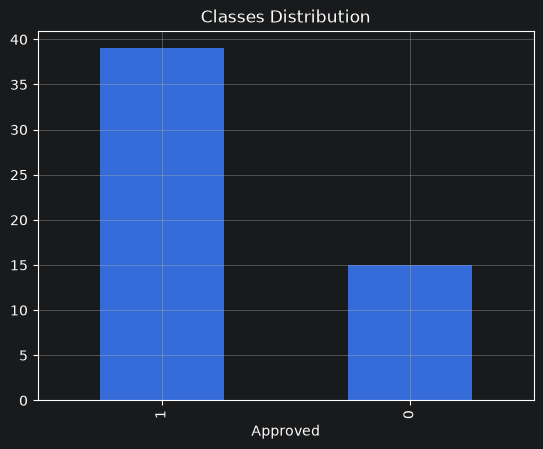

,Income,CreditScore,LoanAmount,Approved
0,30,580,120,0
1,32,585,118,0
2,34,590,115,0
3,35,600,110,0
4,37,605,108,0
5,39,608,107,0
6,40,610,105,0
7,42,615,103,0
8,44,618,102,0
9,45,620,100,0


,Income,CreditScore,LoanAmount,Approved
44,108,812,51,1
45,110,820,50,1
46,112,822,49,1
47,114,825,48,1
48,116,828,47,1
49,118,830,46,1
50,120,832,45,1
51,122,835,44,1
52,124,838,43,1
53,126,840,42,1


,Income,CreditScore,LoanAmount,Approved
count,54.000000,54.000000,54.000000,54.000000
mean,76.055556,723.944444,74.666667,0.722222
std,28.227791,83.636775,22.618243,0.452109
min,30.000000,580.000000,42.000000,0.000000
25%,52.500000,646.250000,55.250000,0.000000
50%,74.500000,735.000000,71.500000,1.000000
75%,99.500000,799.500000,92.750000,1.000000
max,126.000000,840.000000,120.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Income       54 non-null     int64
 1   CreditScore  54 non-null     int64
 2   LoanAmount   54 non-null     int64
 3   Approved     54 non-null     int64
dtypes: int64(4)
memory usage: 1.8 KB


None

In [110]:
loan_data = pd.DataFrame()

loan_data["Income"] = [
    30,
    32,
    34,
    35,
    37,
    39,
    40,
    42,
    44,
    45,
    47,
    49,
    50,
    52,
    54,
    55,
    57,
    59,
    60,
    62,
    64,
    65,
    67,
    69,
    70,
    72,
    74,
    75,
    77,
    79,
    80,
    82,
    84,
    86,
    88,
    90,
    92,
    94,
    96,
    98,
    100,
    102,
    104,
    106,
    108,
    110,
    112,
    114,
    116,
    118,
    120,
    122,
    124,
    126,
]

loan_data["CreditScore"] = [
    580,
    585,
    590,
    600,
    605,
    608,
    610,
    615,
    618,
    620,
    625,
    630,
    640,
    645,
    650,
    660,
    665,
    670,
    680,
    685,
    690,
    700,
    705,
    710,
    720,
    725,
    730,
    740,
    745,
    750,
    760,
    765,
    770,
    775,
    778,
    780,
    785,
    790,
    795,
    798,
    800,
    803,
    806,
    810,
    812,
    820,
    822,
    825,
    828,
    830,
    832,
    835,
    838,
    840,
]

loan_data["LoanAmount"] = [
    120,
    118,
    115,
    110,
    108,
    107,
    105,
    103,
    102,
    100,
    98,
    97,
    95,
    93,
    92,
    90,
    89,
    88,
    85,
    84,
    83,
    80,
    79,
    78,
    75,
    74,
    73,
    70,
    69,
    68,
    65,
    64,
    63,
    62,
    61,
    60,
    59,
    58,
    57,
    56,
    55,
    54,
    53,
    52,
    51,
    50,
    49,
    48,
    47,
    46,
    45,
    44,
    43,
    42,
]

loan_data["Approved"] = [
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
]
print(loan_data["Approved"].value_counts().plot(kind="bar"))
plt.title("Classes Distribution")
plt.grid()
plt.show()
display(loan_data.head(10))
display(loan_data.tail(10))
display(loan_data.describe())
display(loan_data.info())

Accuracy: 100.0%


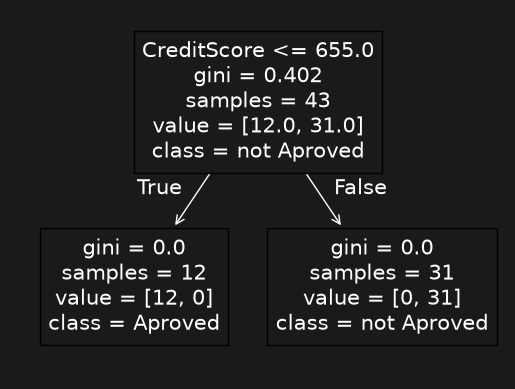

new_customer: [1]


In [111]:
# split data to Train and test set
X_train, X_test, y_train, y_test = train_test_split(
    loan_data.iloc[:, :-1].to_numpy(),
    loan_data.iloc[:, -1].to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=loan_data.iloc[:, -1],
)

tree = DecisionTreeClassifier()

fitted_tree = tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100}%")
feature_names = loan_data.columns[:-1].tolist()
plot_tree(
    fitted_tree, feature_names=feature_names, class_names=["Aproved", "not Aproved"]
)
plt.show()

new_customer = [[68, 710, 78]]
new_pred = tree.predict(new_customer)
print(f"new_customer: {new_pred}")

# Question 2

In [112]:
train_acc = accuracy_score(y_train, tree.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f"{"Train Accuracy":<15}:{train_acc*100}%")
print(f"{"Test Accuracy":<15}:{test_acc*100}%\n{"-"*23}")
tree_3 = DecisionTreeClassifier(max_depth=3)
tree_3.fit(X_train, y_train)
y_pred3 = tree_3.predict(X_test)
train_acc = accuracy_score(y_train, tree_3.predict(X_train))
test_acc = accuracy_score(y_test, y_pred3)
print(f"max depth = 3\n{"Train Accuracy":<15}:{train_acc*100}%")
print(f"{"Test Accuracy":<15}:{test_acc*100}%")

Train Accuracy :100.0%
Test Accuracy  :100.0%
-----------------------
max depth = 3
Train Accuracy :100.0%
Test Accuracy  :100.0%


# Question 3

In [113]:
customer_data = pd.DataFrame()
customer_data["AnnualIncome"] = [
    15,
    18,
    20,
    22,
    25,
    28,
    30,
    32,
    35,
    38,
    40,
    42,
    45,
    48,
    50,
    52,
    55,
    58,
    60,
    62,
    65,
    68,
    70,
    72,
    75,
    78,
    80,
    82,
    85,
    88,
    90,
    95,
    100,
    105,
    110,
    115,
    120,
    125,
    130,
    135,
    140,
    145,
    150,
    160,
    170,
]
customer_data["SpendingScore"] = [
    90,
    85,
    80,
    82,
    78,
    75,
    72,
    70,
    68,
    65,
    62,
    60,
    58,
    55,
    52,
    50,
    48,
    45,
    42,
    40,
    38,
    35,
    32,
    30,
    28,
    25,
    23,
    20,
    18,
    15,
    12,
    10,
    8,
    15,
    18,
    20,
    22,
    25,
    28,
    30,
    32,
    35,
    38,
    40,
    42,
]
display(customer_data.head())
customer_data.describe()

,AnnualIncome,SpendingScore
0,15,90
1,18,85
2,20,80
3,22,82
4,25,78


,AnnualIncome,SpendingScore
count,45.000000,45.000000
mean,76.177778,42.577778
std,42.107162,22.778068
min,15.000000,8.000000
25%,42.000000,25.000000
50%,70.000000,38.000000
75%,105.000000,60.000000
max,170.000000,90.000000


In [114]:
k_means = KMeans(n_clusters=3,random_state=42)
k_means.fit(customer_data)
customer_data["Cluster"] = k_means.predict(customer_data)
centroids = k_means.cluster_centers_


,AnnualIncome,SpendingScore,Cluster
0,15,90,2
1,18,85,2
2,20,80,2
3,22,82,2
4,25,78,2


,AnnualIncome,SpendingScore,Cluster
40,140,32,1
41,145,35,1
42,150,38,1
43,160,40,1
44,170,42,1


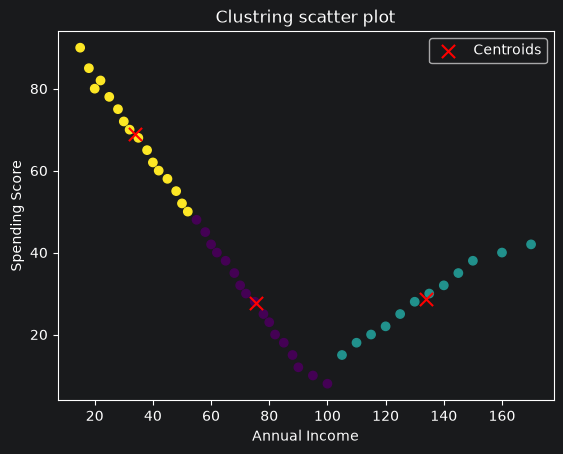

In [115]:
display(customer_data.head(5))
display(customer_data.tail(5))
plt.scatter(customer_data["AnnualIncome"], customer_data["SpendingScore"],c=customer_data['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1],c="red",marker="x",s=90,label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.title("Clustring scatter plot")
plt.show()

,AnnualIncome,SpendingScore,Cluster
0,15,90,0
1,18,85,0
2,20,80,0
3,22,82,0
4,25,78,0


,AnnualIncome,SpendingScore,Cluster
40,140,32,1
41,145,35,1
42,150,38,1
43,160,40,1
44,170,42,1


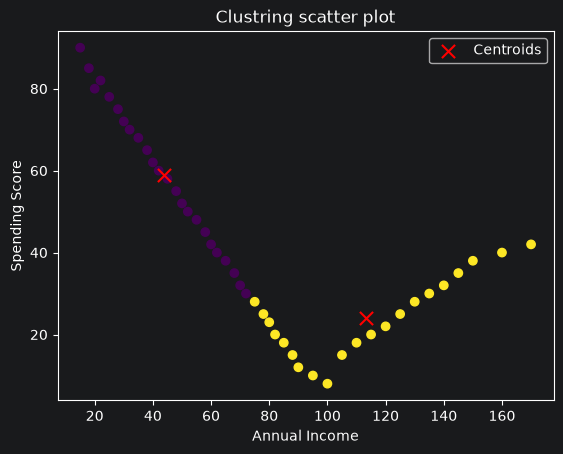

In [116]:
k_means = KMeans(n_clusters=2,random_state=42)
k_means.fit(customer_data)
customer_data["Cluster"] = k_means.predict(customer_data)
centroids = k_means.cluster_centers_

display(customer_data.head(5))
display(customer_data.tail(5))
plt.scatter(customer_data["AnnualIncome"], customer_data["SpendingScore"],c=customer_data['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1],c="red",marker="x",s=90,label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.title("Clustring scatter plot")
plt.show()


,AnnualIncome,SpendingScore,Cluster
0,15,90,2
1,18,85,2
2,20,80,2
3,22,82,2
4,25,78,2


,AnnualIncome,SpendingScore,Cluster
40,140,32,1
41,145,35,1
42,150,38,1
43,160,40,1
44,170,42,1


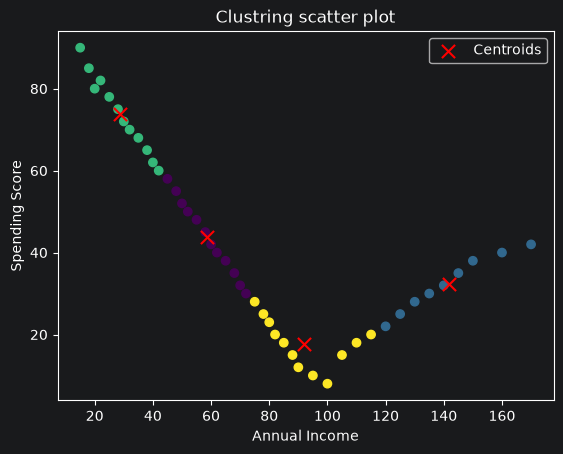

In [117]:
k_means = KMeans(n_clusters=4,random_state=42)
k_means.fit(customer_data)
customer_data["Cluster"] = k_means.predict(customer_data)
centroids = k_means.cluster_centers_

display(customer_data.head(5))
display(customer_data.tail(5))
plt.scatter(customer_data["AnnualIncome"], customer_data["SpendingScore"],c=customer_data['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1],c="red",marker="x",s=90,label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.title("Clustring scatter plot")
plt.show()

# Extra